# Multi-Task Omics — `multibench` end-to-end tutorial

This notebook takes one dataset through the whole workflow: find a method, resolve its inputs, check its parameters, run it, score it and plot the scores. The dataset is `D11`: 2,864 blood cells measured with CITE-seq, which gives RNA and surface protein (ADT) for each cell.

```
inputs_for  →  params_for  →  run  →  evaluate  →  plot
 (data)        (tuning)      (method)  (metrics)   (figure)
```

## 0. Setup

The first cell installs `multibench-sc` if it is missing. Methods run only on Linux, each in its own environment. Set `INSTALL_ENVS = True` on Linux or Colab to download Matilda's environment. On macOS and Windows every cell still runs and uses stored outputs instead.

<details>
<summary>Details</summary>

With `INSTALL_ENVS = False` no environment is downloaded. Section 4 then loads Matilda's output from the benchmark's Linux machine instead of running Matilda.

With `INSTALL_ENVS = True`, the install cell downloads a prebuilt environment, with no conda needed. On Colab, choose a GPU runtime first: Runtime -> Change runtime type -> T4 GPU. On a CPU runtime the smaller CPU build is installed, and training is much slower.

Sections 7 and 8 read the `results/` folder when the notebook runs from the repository's `notebooks/` folder. Elsewhere, as on Colab, they read the package's stored results, which have no `status` or run-time columns.

</details>

In [1]:
import importlib.metadata, importlib.util, sys
if importlib.util.find_spec("multibench") is None:
    # keep the numpy / pandas this interpreter already has
    pins = [f"{p}=={importlib.metadata.version(p)}" for p in ("numpy", "pandas") if importlib.util.find_spec(p)]
    !{sys.executable} -m pip -q install "multibench-sc>=0.3.2" {" ".join(pins)}
    importlib.invalidate_caches()
    # not on PyPI yet: install from GitHub
    if importlib.util.find_spec("multibench") is None:
        !{sys.executable} -m pip -q install "git+https://github.com/DSichang/scMultiBench.git" {" ".join(pins)}
else:
    print("multibench already installed")

multibench already installed


In [2]:
# False: no environment is downloaded; method cells use stored outputs.
# True (Linux or Colab): run the methods here; no conda needed.
# 1 env, 0.6 GB to download on a CPU host, 3.0 GB on a GPU host.
INSTALL_ENVS = False

In [3]:
%matplotlib inline

import warnings
for _w in (FutureWarning, DeprecationWarning):   # hide deprecation noise
    warnings.filterwarnings("ignore", category=_w)

import pandas as pd
import multibench as mtb

print("multibench", mtb.__version__)

from pathlib import Path
# stored results used in sections 7 and 8
RESULTS = Path("results")

multibench 0.3.2


### Environments

Methods run in their own environments, and the next cell lists the environment of each method. The cell after it installs Matilda's environment for section 4, but only when `INSTALL_ENVS = True` on Linux.

<details>
<summary>Details</summary>

`multibench env install --methods Matilda --packed --run` installs the same environment from a terminal. Give `--methods` a comma-separated list, or use `--category vertical` for every vertical method.

`--packed` downloads a prebuilt archive, so conda is not needed. Without it, conda builds the environment from its lockfile. Without `--run`, `env install` only prints what it would install, and `multibench env doctor --methods Matilda` shows whether the environment is installed.

Environments are unpacked under `mtb.config.DEFAULT.envs_dir`. Set it before the install cell to use another disk.

</details>

In [4]:
DATASET  = "D11"
CATEGORY = "vertical"
MODALITIES = ["rna", "adt"]

METHODS = ["Concerto", "MOFA2", "Matilda", "Multigrate", "Seurat_WNN", "UINMF",
           "VIMCCA", "moETM", "scMDC", "scMM", "scMSI", "scMoMaT", "sciPENN", "totalVI"]

pd.DataFrame([{"method": m, "env": mtb.method_info(m)["env"]} for m in METHODS])

,method,env
0,Concerto,scmb_concerto
1,MOFA2,MOFA2_env
2,Matilda,matilda
3,Multigrate,scmb_multigrate2
4,Seurat_WNN,scmb_seurat5
5,UINMF,scmb_r
6,VIMCCA,scmb_vimcca
7,moETM,env_moETM
8,scMDC,scmb_scmdc
9,scMM,scmb_scmm2


In [5]:
import sys
if not INSTALL_ENVS:
    print("INSTALL_ENVS is False: no environment is downloaded")
elif sys.platform != "linux":
    print("method environments run only on Linux: skipped on", sys.platform)
else:
    # dry run: sizes only
    plan = mtb.env.install(['Matilda'], category=CATEGORY)
    todo = [r for r in plan if not r["exists"]]
    print(f"{len(todo)} of {len(plan)} envs to download, {sum(r['archive_bytes'] or 0 for r in todo) / 1e9:.1f} GB")
    for r in mtb.env.install(['Matilda'], category=CATEGORY, packed=True, dry_run=False):
        print(f"{r['env']:20s} {r['state']}")

INSTALL_ENVS is False: no environment is downloaded


## 1. Discovery: which methods fit my data?

`find_methods` lists the methods that support a category and a set of modalities. `method_info` describes one method.

In [6]:
vertical_rna_adt = mtb.find_methods(category="vertical", modalities=["rna", "adt"])
print(len(vertical_rna_adt), "methods support vertical [rna, adt]")
print(sorted(vertical_rna_adt))

14 methods support vertical [rna, adt]
['Concerto', 'MOFA2', 'Matilda', 'Multigrate', 'Seurat_WNN', 'UINMF', 'VIMCCA', 'moETM', 'scMDC', 'scMM', 'scMSI', 'scMoMaT', 'sciPENN', 'totalVI']


In [7]:
info = mtb.method_info("Matilda")
{k: info[k] for k in ("id", "language", "categories", "tasks", "env", "gpu", "status")}

{'id': 'Matilda',
 'language': 'python',
 'categories': ['vertical'],
 'tasks': ['clustering', 'dimension_reduction'],
 'env': 'matilda',
 'gpu': 'used when present',
 'status': 'verified'}

## 2. Data: resolve the inputs

`mtb.data.fetch` downloads D11 once. `inputs_for` returns the files a method needs from a dataset. With `check=True`, it raises an error now if a file is missing.

In [8]:
# downloaded once, then reused
mtb.data.fetch(DATASET)
# the arguments are dataset, category, method
inputs = mtb.inputs_for(DATASET, CATEGORY, "Matilda",
                        modalities=MODALITIES, check=True)
inputs

{'rna': '/tmp/mbc/multibench/data/D11/rna.h5',
 'adt': '/tmp/mbc/multibench/data/D11/adt.h5',
 'cty': '/tmp/mbc/multibench/data/D11/cty.csv'}

In [9]:
# cell-type labels used later for the metrics
mtb.labels_for(DATASET)

{'cty': '/tmp/mbc/multibench/data/D11/cty.csv'}

## 3. Parameters: what can I tune?

`params_for` lists a method's parameters. `defaults` are passed on every run, and `tunable` are the options the method's script accepts. Change any of them with `run(..., params={...})`.

<details>
<summary>Details</summary>

Nine of these 14 methods expose no parameters on their command line, so the package cannot tune them. The second table shows which.

The values under `tunable` are the script's own defaults, and `p["effective"]` holds the value a run uses. The [`params_for` reference](https://dsichang.github.io/scMultiBench/reference/discover/#multibench.discover.params_for) lists the other keys.

</details>

In [10]:
p = mtb.params_for("Matilda", CATEGORY, MODALITIES)
print("defaults:", p["defaults"])
print("tunable :", list(p["tunable"])[:10])

defaults: {'epochs': 30, 'seed': 1, 'device': 'auto'}
tunable : ['augmentation', 'batch_size', 'device', 'epochs', 'hidden_adt', 'hidden_atac', 'hidden_rna', 'lr', 'seed', 'z_dim']


In [11]:
rows = []
for m in METHODS:
    q = mtb.params_for(m, CATEGORY, MODALITIES)
    rows.append({"method": m, "n_tunable": len(q["tunable"]),
                 "defaults": q["defaults"],
                 "example_tunable": ", ".join(sorted(q["tunable"])[:4]) or "(none - hardcoded upstream)"})
pd.DataFrame(rows).sort_values("n_tunable", ascending=False).reset_index(drop=True)

,method,n_tunable,defaults,example_tunable
0,scMDC,24,{'nbatch': 1},"batch_size, cutoff, data_file, device"
1,scMM,19,"{'model': 'rna_protein', 'no_cuda': True}","analytics, batch_size, deterministic_warmup, e..."
2,Matilda,10,"{'epochs': 30, 'seed': 1, 'device': 'auto'}","augmentation, batch_size, device, epochs"
3,Multigrate,3,"{'epochs': 200, 'bs': 256, 'lr': 0.001}","bs, epochs, lr"
4,sciPENN,1,{},seed
5,Concerto,0,{},(none - hardcoded upstream)
6,MOFA2,0,{},(none - hardcoded upstream)
7,Seurat_WNN,0,{},(none - hardcoded upstream)
8,UINMF,0,{},(none - hardcoded upstream)
9,VIMCCA,0,{},(none - hardcoded upstream)


## 4. Run a method

`run` runs Matilda in its environment and loads the embedding it writes. An embedding is a table of numbers with one row per cell. `params={"epochs": 5}` shortens training for this demo. Without the environment, the cell prints one line and loads Matilda's output from the benchmark's Linux machine instead.

<details>
<summary>Details</summary>

That output comes from `mtb.data.fetch_outputs`, which downloads the `run_all` outputs for `D11`. The cell reloads them with `mtb.load_batch` and reads Matilda's embedding. If the download fails, `emb` is `None`. Section 5 then shows Matilda's stored scores (`load_results(source="rerun")`), and section 6 plots the stored table alone.

`res.obs_names` holds the cell barcodes of the rows of `res.output`. When `res.obs_names` matches `adata.obs_names`, `adata.obsm["X_Matilda"] = res.output` adds the result to your AnnData.

`mtb.run(..., dry_run=True)` prints the command without running it. It works on any computer, so you can check a call on a laptop before you run it on Linux.

</details>

In [12]:
import h5py

def replacement(dataset, method):
    """`method`'s embedding from the run_all outputs of the benchmark's Linux machine; None if that download fails."""
    try:
        batch = mtb.load_batch(mtb.data.fetch_outputs(dataset), methods=[method])
        with h5py.File(Path(batch.out_dir) / f"{method}_{dataset}" / "embedding.h5") as f:
            emb = f["data"][()]
        print(f"replacement: {method}'s embedding from the run_all outputs for {dataset} of the benchmark's Linux machine")
        return emb
    # offline, or the outputs are not published yet
    except Exception as e:
        print(f"replacement: the package's stored scores for {method}. {type(e).__name__} from fetch_outputs: {e}")
        return None

check = mtb.scan(DATASET, CATEGORY, methods=["Matilda"])
if check.env_ok.any():
    res = mtb.run(method="Matilda", category=CATEGORY, inputs=inputs,
                  out_dir="/tmp/tutorial/Matilda_D11",
                  params={"epochs": 5})
    emb = res.output
else:
    print("no method environment on this computer: the run is skipped, and outputs computed elsewhere replace it")
    emb = replacement(DATASET, "Matilda")

print("embedding:", None if emb is None else emb.shape)

[scan] 1 of 2 rows has its input files. 0 of 2 have their environment installed. Method environments run only on Linux. On this computer you can check files, score embeddings and plot. The commands use this computer's paths, so run scan again on the Linux machine.


no method environment on this computer: the run is skipped, and outputs computed elsewhere replace it
replacement: Matilda's embedding from the run_all outputs for D11 of the benchmark's Linux machine
embedding: (2864, 100)


### Not every method returns an embedding

Check a method's output kind before computing metrics. Twelve of these methods return an embedding, and two return a graph. Scoring a graph as an embedding gives a meaningless result and no error.

<details>
<summary>Details: the two graph methods</summary>

`Seurat_WNN` writes only a neighbour graph, so there is nothing to score. `scMoMaT` writes a KNN graph plus a UMAP embedding, which `run` returns in `res.extra`.

`mtb.run_all` checks the kind for you. It scores scMoMaT through its UMAP, with status `CHAIN_OK_GRAPH_METHOD`, and reports Seurat_WNN as `RUN_OK_NO_EMBEDDING`.

</details>

In [13]:
rows = []
for m in METHODS:
    # the variant of the method for this category and these modalities
    v = next(v for v in mtb.method_info(m)["supports"]
             if v["category"] == CATEGORY and sorted(v["modalities"]) == sorted(MODALITIES))
    rows.append({"method": m, "output_kind": v["output_kind"]})
pd.DataFrame(rows).sort_values(["output_kind", "method"]).reset_index(drop=True)

,method,output_kind
0,Concerto,embedding
1,MOFA2,embedding
2,Matilda,embedding
3,Multigrate,embedding
4,UINMF,embedding
5,VIMCCA,embedding
6,moETM,embedding
7,scMDC,embedding
8,scMM,embedding
9,scMSI,embedding


## 5. Evaluate: scIB metrics

`evaluate` scores the embedding against the cell-type labels. Pass the labels in the embedding's cell order. The first line selects the Leiden backend of the stored tables, so that section 6 can compare this run with them.

<details>
<summary>Details</summary>

`metrics="clustering"` computes ARI, NMI, ASW, iASW, iF1 and cLISI. D11 has a single batch, so the batch metrics do not apply.

The default Leiden backend is igraph, which is faster. The two backends can move ARI by up to about 0.1.

</details>

In [14]:
# the Leiden backend of the stored tables
mtb.config.DEFAULT.leiden_flavor = "leidenalg"
if emb is not None:
    scores = mtb.evaluate(emb, labels=mtb.labels_for(DATASET), category=CATEGORY,
                          metrics="clustering")
else:
    print("no embedding on this computer for Matilda: its stored scores are shown instead")
    stored = mtb.load_results(CATEGORY, dataset=DATASET, source="rerun", methods=["Matilda"])
    scores = pd.DataFrame({"Value": dict(zip(stored.metric, stored.value))})
scores

Clustering 2,864 cells at 10 resolutions for ARI, NMI and iF1, with the leidenalg Leiden backend. This takes from seconds to a few minutes. To skip it, pass metrics= without ARI, NMI and iF1.


,Value
ARI,0.873072
NMI,0.869760
ASW,0.597756
iASW,0.581653
iF1,0.817894
cLISI,0.996140


## 6. Plot

`plot.bubble` compares methods, so the cell adds this run to the stored `D11` results and plots them together. `to_long` first reshapes the scores into a long table, with one row per metric.

<details>
<summary>Details</summary>

The new row is `Matilda (this run)`, next to the stored `Matilda` row. Your own method can take any name.

The stored tables hold only the demo datasets. Rows from your own dataset go in a figure of their own.

Without an embedding, the cell plots the stored table alone.

</details>

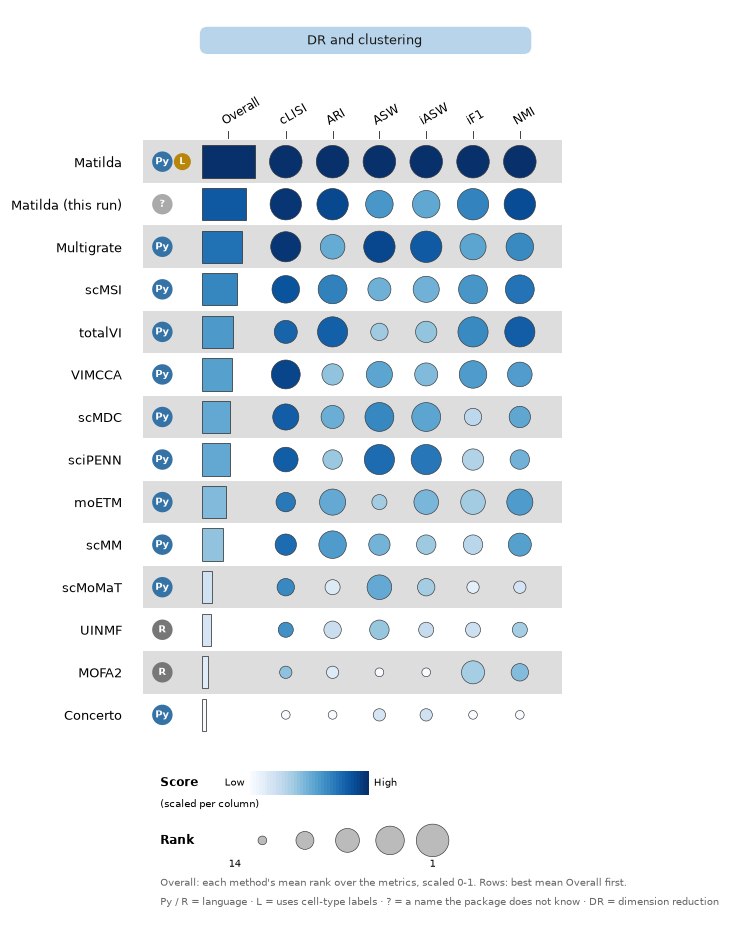

In [15]:
stored = mtb.load_results(CATEGORY, dataset=DATASET, source="rerun")
if emb is not None:
    mine = mtb.to_long(scores, method="Matilda (this run)", dataset=DATASET, category=CATEGORY)
    long = pd.concat([stored, mine], ignore_index=True)
else:
    long = stored
fig = mtb.plot.bubble(long)
fig.set_dpi(110)
display(fig)

## 7. Comparing all 14 methods

Running all 14 methods takes hours, so this section loads their stored D11 results. The figure in section 6 shows their scores, and the table adds each run's status and run time.
Seurat_WNN has no scores: it returns a graph, not an embedding.

In [16]:
def stored_table(kind, dataset):
    """The `summary` or `long_all` table for `dataset`: from results/, else from the package's stored results."""
    if RESULTS.is_dir():
        return pd.read_csv(RESULTS / f"{kind}_{dataset}.csv")
    long = mtb.load_results(dataset=dataset, source="rerun")
    if kind == "long_all":
        return long
    return long.pivot_table(index="method", columns="metric", values="value").rename_axis(columns=None).reset_index()

if not RESULTS.is_dir():
    print("no results/ folder here: the package's stored results are used instead, without status or run-time columns")
summary = stored_table("summary", "D11")
summary[[c for c in ["method", "status", "run_sec", "ARI", "NMI", "ASW"]
         if c in summary.columns]]

,method,status,run_sec,ARI,NMI,ASW
0,Concerto,CHAIN_OK,1387.6,0.3724,0.4705,0.5086
1,MOFA2,CHAIN_OK,868.4,0.4444,0.6691,0.4733
2,Matilda,CHAIN_OK,189.2,0.9238,0.9186,0.6793
3,Multigrate,CHAIN_OK,1276.6,0.6556,0.7643,0.6609
4,UINMF,CHAIN_OK,261.2,0.4983,0.6286,0.5541
5,VIMCCA,CHAIN_OK,548.8,0.5985,0.7300,0.5847
6,moETM,CHAIN_OK,428.3,0.6605,0.7323,0.5478
7,scMDC,CHAIN_OK,888.1,0.6494,0.7111,0.6104
8,scMM,CHAIN_OK,234.9,0.6939,0.7228,0.5722
9,scMSI,CHAIN_OK,8163.9,0.7518,0.8019,0.5743


---

## 8. The other integration categories

Each category has its own reference dataset. Repeat the calls above with its `dataset`, `category` and a modality list the method accepts. `mtb.method_info(m)["supports"]` shows them. For a dataset with several label files, pass `labels_for(dataset, category, method)` to `evaluate`, as Label order below shows.

| category | data | reference dataset |
|---|---|---|
| vertical | several modalities measured in the same cells | D11 (2,864 cells) |
| diagonal | RNA and ATAC measured in different cells | D28 (11,014 cells) |
| mosaic | several batches that share only some modalities | D45 (32,151 cells) |
| cross | several batches, each with RNA and ADT | D52 (23,478 cells) |

<details>
<summary>Details: method counts</summary>

The next cell counts the methods that pass `scan`'s file check (`files_ok`) on each dataset. `find_methods` alone checks only the modality types. A dataset must be on disk to be counted.

</details>

In [17]:
SCENARIOS = {
    "vertical": dict(dataset="D11", modalities=["rna", "adt"]),
    "diagonal": dict(dataset="D28", modalities=["rna", "atac"]),
    "mosaic":   dict(dataset="D45", modalities=["rna1", "rna2", "atac2", "atac3"]),
    "cross":    dict(dataset="D52", modalities=["rna1", "rna2", "adt1", "adt2"]),
}

for cat, s in SCENARIOS.items():
    ds = s["dataset"]
    if not (mtb.config.DEFAULT.data_path / ds).is_dir():
        print(f"{cat:9s} {ds:5s} -> not on disk: mtb.data.fetch({ds!r}) first to count its methods")
        continue
    got = mtb.find_methods(category=cat, modalities=[m.rstrip("123") for m in s["modalities"]])
    # keep the methods with a variant for this dataset's files
    sc = mtb.scan(ds, cat, methods=got, verbose=False)
    print(f"{cat:9s} {ds:5s} -> {sc[sc.files_ok].method.nunique():2d} methods")

vertical  D11   -> 14 methods
diagonal  D28   -> 13 methods
mosaic    D45   ->  4 methods


cross     D52   ->  8 methods


### Stored results for each category

The next cell prints the stored summary of each of the other three categories.

<details>
<summary>Details</summary>

Conos has an ARI near 0 on D28. `load_results(source="rerun")` flags this row with `DegenerateRerunWarning`. Leave it out when ranking.

</details>

In [18]:
for cat, ds in [("diagonal", "D28"), ("mosaic", "D45"), ("cross", "D52")]:
    df = stored_table("summary", ds)
    cols = [c for c in ["method", "status", "run_sec", "ARI", "NMI", "ASW"] if c in df.columns]
    print(f"\n{cat} ({ds})")
    print(df[cols].to_string(index=False))


diagonal (D28)
     method   status  run_sec    ARI    NMI    ASW
      Conos CHAIN_OK    712.5 0.0004 0.0226 0.4301
   MultiMAP CHAIN_OK   2040.2 0.2368 0.4966 0.5529
     Portal CHAIN_OK    400.4 0.4798 0.6144 0.5186
     SCALEX CHAIN_OK   2232.3 0.5744 0.5859 0.5320
  Seurat_v3 CHAIN_OK   3364.6 0.6055 0.6339 0.4724
     VIPCCA CHAIN_OK    334.8 0.1518 0.3756 0.4785
       iNMF CHAIN_OK    120.2 0.4721 0.5136 0.4946
online_iNMF CHAIN_OK     80.7 0.3749 0.4690 0.4666
    scJoint CHAIN_OK    208.9 0.6178 0.6377 0.5349
     sciCAN CHAIN_OK  15735.0 0.1877 0.3688 0.5133
    uniPort CHAIN_OK   4133.0 0.5994 0.6198 0.5320
   scBridge CHAIN_OK    963.4 0.7005 0.7448 0.6536

mosaic (D45)
    method   status  run_sec    ARI    NMI    ASW
    Cobolt CHAIN_OK   3636.2 0.8173 0.8078 0.6120
   MultiVI CHAIN_OK  12041.7 0.8185 0.8099 0.5748
Multigrate CHAIN_OK  10368.1 0.7754 0.7715 0.5463
     SMILE CHAIN_OK   1915.5 0.3667 0.5800 0.5615

cross (D52)
  method                status  run_sec    A

### Label order

A method that stacks several batches or modalities sets its own cell order. `labels_for(dataset, category, method)` returns the label files in that order, and `evaluate` takes the dict as it is. A wrong order gives a wrong score and no error.

```python
# StabMap's order: cty3, cty1, cty2
mtb.evaluate(emb, labels=mtb.labels_for("D52", "cross", "StabMap"))
```

<details>
<summary>Details</summary>

The `label_order` column of each stored summary shows the order used. StabMap on D52 puts batch 3 first (`cty3+cty1+cty2`), and uniPort on D28 puts ATAC before RNA. `labels_for` with the method returns both orders.

Concerto's stored D52 run also put batch 3 first. Concerto stacks its batches in the order in which the file system lists its per-batch files. `mtb.run` lists them by batch number, so `labels_for("D52", "cross", "Concerto")` returns `cty1, cty2, cty3`, the order of a new run. To score the stored run, set `label_order=` to its `label_order` column.

A dict you build or reorder yourself must be in the default order: `cty1, cty2, ...`, and RNA before ATAC. Name any other order with `label_order=`.

A method that reads only some batches gets only their label files: `labels_for("D52", "cross", "UINMF")` returns `cty1` and `cty2`.

`mtb.run_all` tries every label order that matches the cell count and keeps the one with the highest ARI. It reports that order in the summary columns `label_order` and `label_order_confidence`.

</details>

### Reading the bubble chart

In [`plot.bubble`](https://dsichang.github.io/scMultiBench/reference/plot/#multibench.plot.bubble.bubble), size is a rank and colour a scaled value, both relative to the methods plotted. Small score gaps can therefore look large. Read the values in the table below the figure.

<details>
<summary>Details</summary>

On D52, sciPENN (0.6947), UINMF (0.6905) and StabMap (0.6880) differ by less than 0.007 ARI but get different bubble sizes.

A column whose rows all hold the same value is drawn grey, and the note under the figure names it. A figure of one method is grey everywhere.

</details>

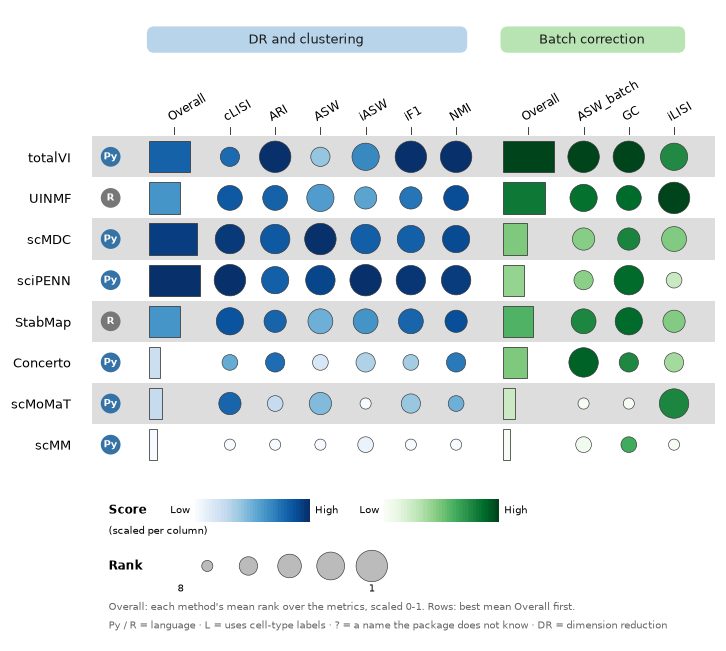

,method,ARI,NMI,ASW
0,Concerto,0.6741,0.7371,0.5175
1,StabMap,0.6880,0.7760,0.5569
2,UINMF,0.6905,0.7772,0.5668
3,scMDC,0.7048,0.7791,0.6159
4,scMM,0.3745,0.5715,0.4990
5,scMoMaT,0.4738,0.6855,0.5512
6,sciPENN,0.6947,0.7914,0.6062
7,totalVI,0.7668,0.8030,0.5455


In [19]:
fig = mtb.plot.bubble(stored_table("long_all", "D52"))
fig.set_dpi(110)
display(fig)

stored_table("summary", "D52")[["method", "ARI", "NMI", "ASW"]]

### Run time

Some methods take hours even on small datasets. Check `mtb.method_info(m)["runtime"]` before running a method.

<details>
<summary>Details</summary>

Some observed run times:

| method | dataset (cells) | run time |
|---|---|---|
| sciPENN | D11 (2,864) | 144 s |
| scJoint | D28 (11,014) | 209 s |
| scMSI | D11 (2,864) | 2.3 h |
| MultiVI | D45 (32,151) | 3.3 h |
| sciCAN | D28 (11,014) | 4.4 h |

Methods that use a GPU take much longer without one. `mtb.method_info(m)["gpu"]` says whether a method uses one.

A `run_all(timeout=...)` run that exceeds the limit ends with status `TIMEOUT`. Allow hours for the slow methods.

</details>

## Summary

| Step | API |
|---|---|
| pick a method | `find_methods`, `method_info` |
| resolve data | `inputs_for`, `labels_for` |
| inspect tuning | `params_for` |
| run | `run(..., params={...})` |
| metrics | `evaluate`, `to_long` |
| figure | `plot.bubble` |
| environments | `mtb.env.*`, `multibench env doctor/install` |